In [1]:
install.packages("pls")
install.packages("plsVarSel")
install.packages("Metrics")


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done




Target: Jsc 


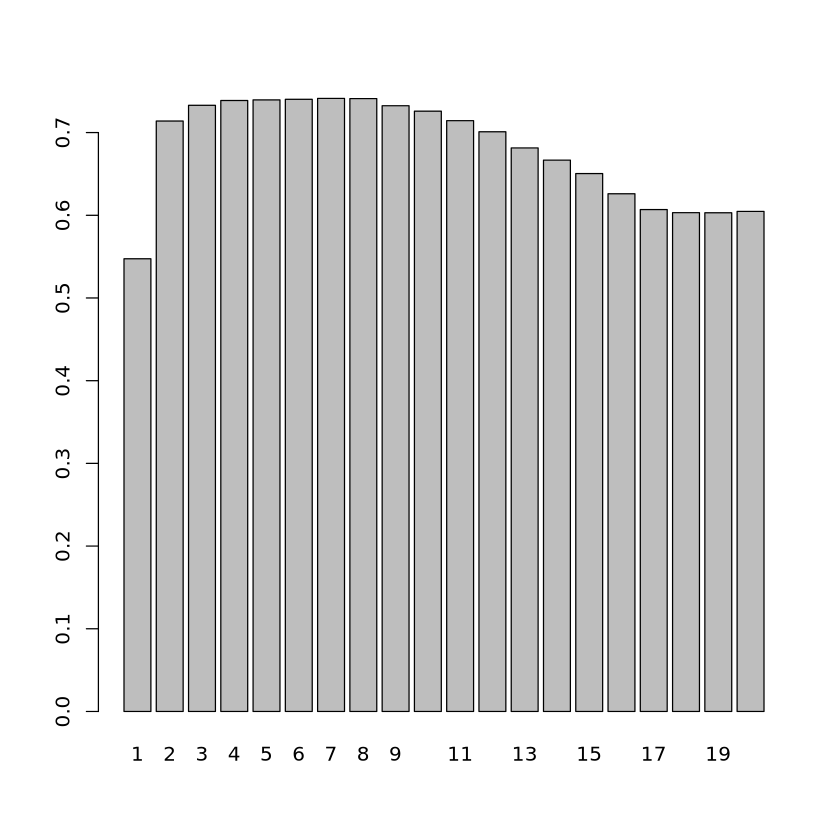

R2      = 0.8968 
corALL  = 0.947 
RMSE    = 1.6229 


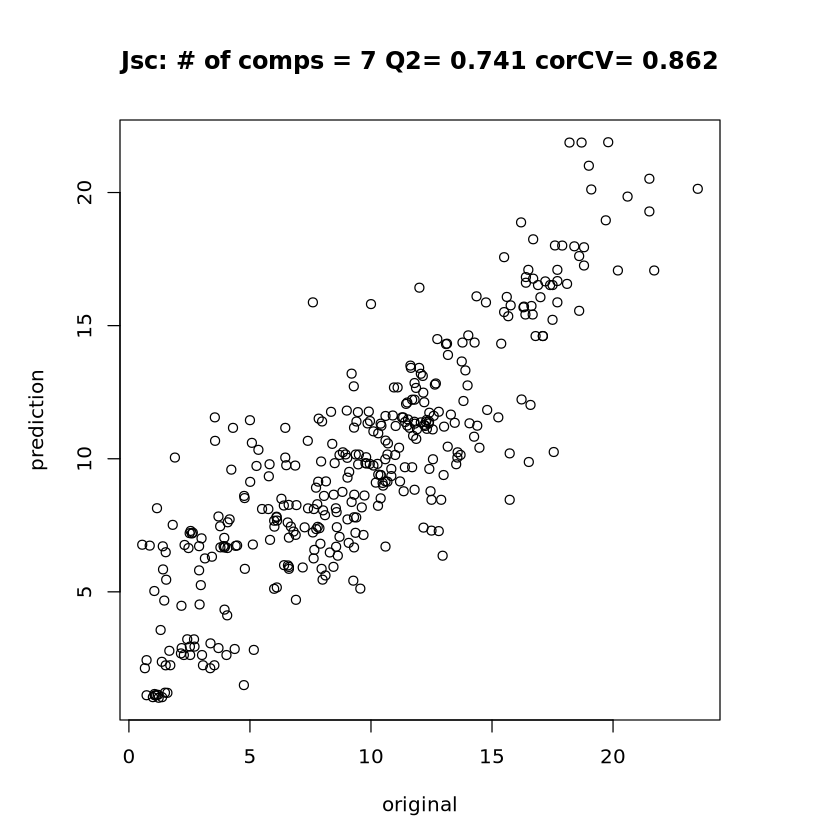


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                     SMILESsnamep1M_PffBT4T2OD 
                                                                                                       1.62329 
                                                                                                      MnkDap1M 
                                                                                                       1.01119 
                                                                                       SMILESsnamep1M_C3DPPTTT 
                                                                                                       0.92532 
                                                                                     SMILESsnamep1M_PBTff4T2OD 
                                                                                                       0.79806 
                            

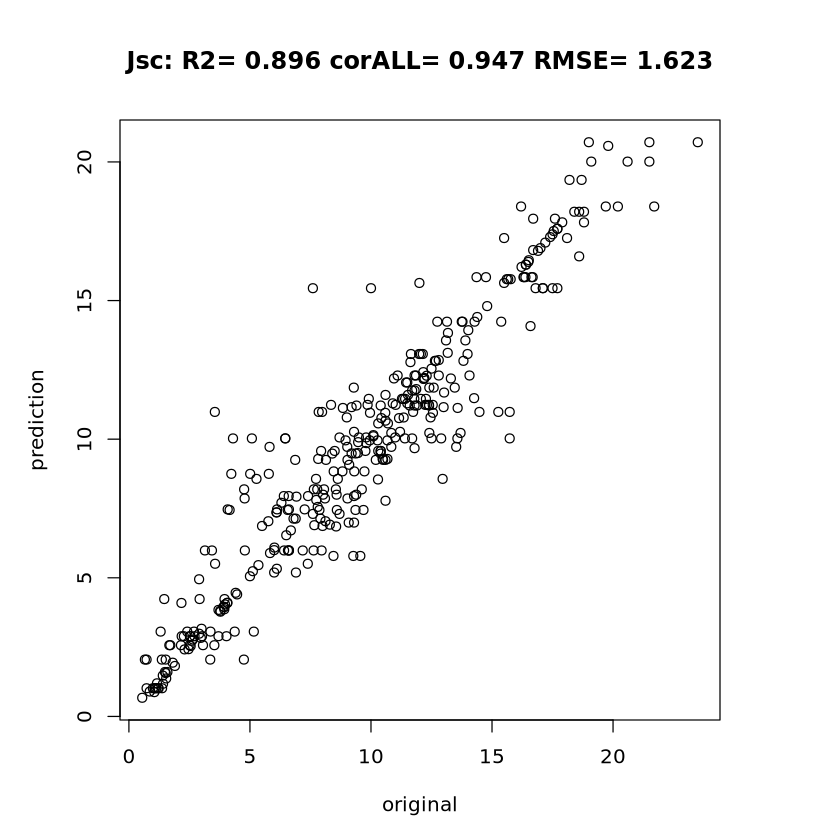


Target: Voc 


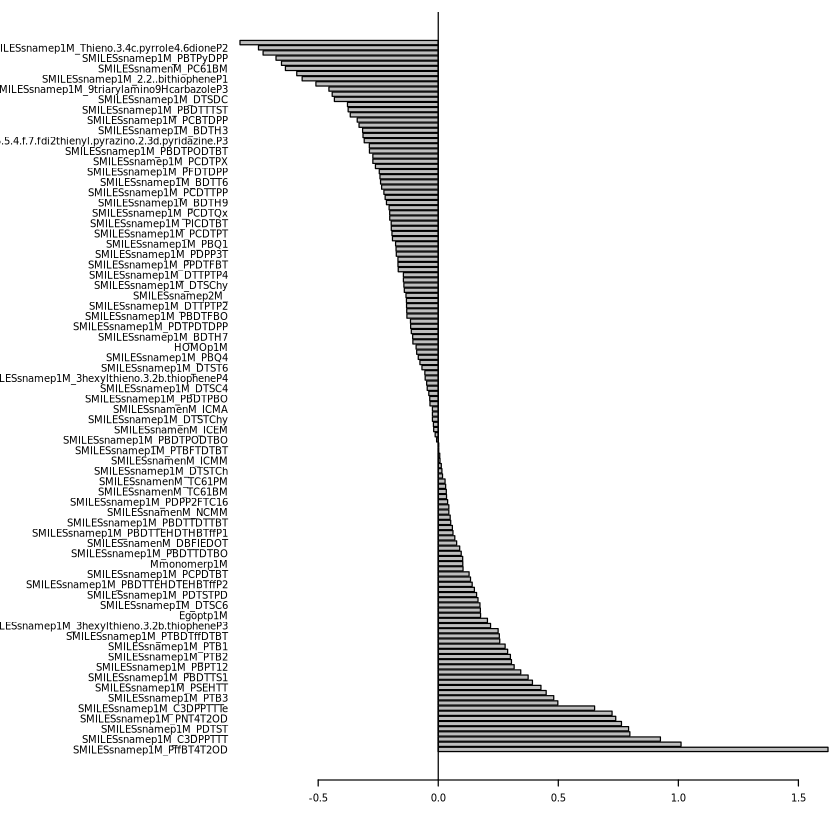

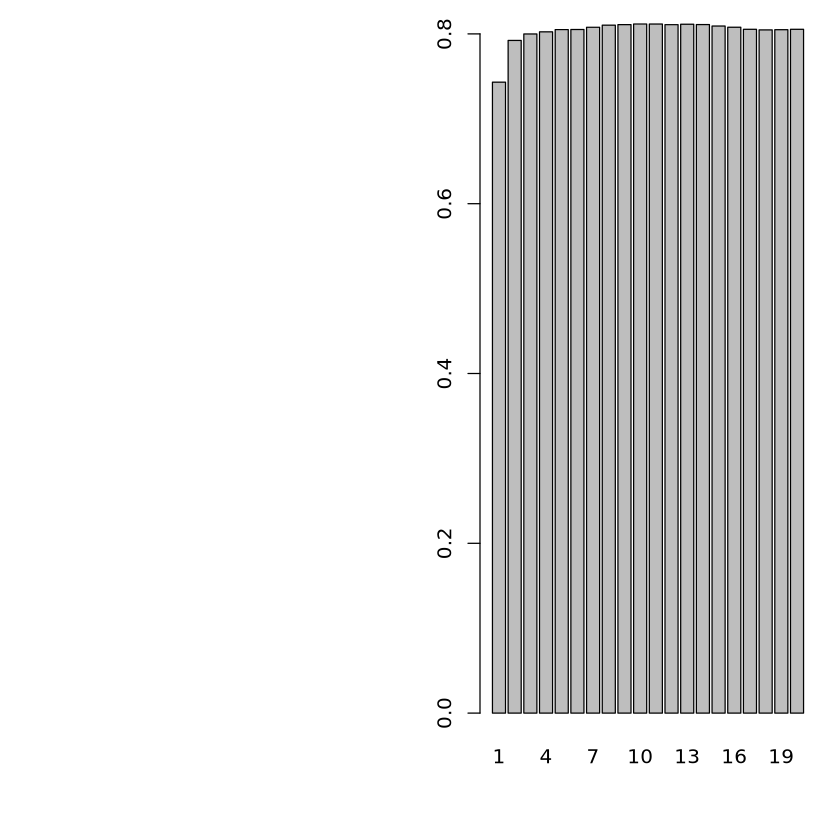

R2      = 0.9511 
corALL  = 0.9753 
RMSE    = 0.0335 


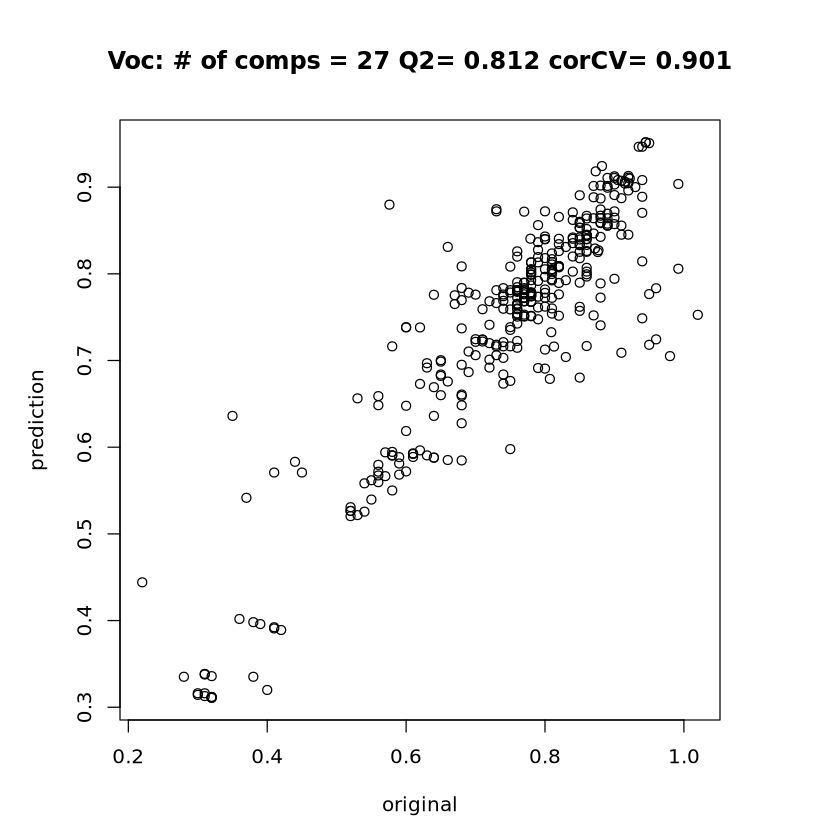


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                                       HOMOp1M 
                                                                                                       0.11009 
                                                                                                       LUMOp1M 
                                                                                                       0.08235 
                                                                                       SMILESsnamep1M_BTIBDTP2 
                                                                                                       0.06591 
                                                                                           SMILESsnamep1M_PBQ1 
                                                                                                       0.04679 
                            

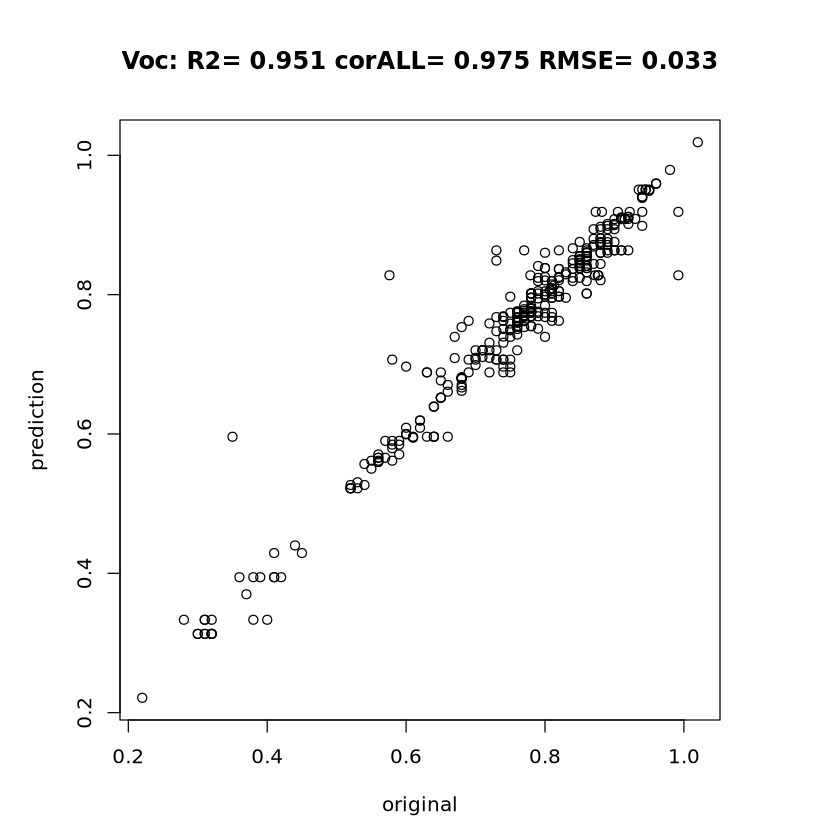


Target: FF 


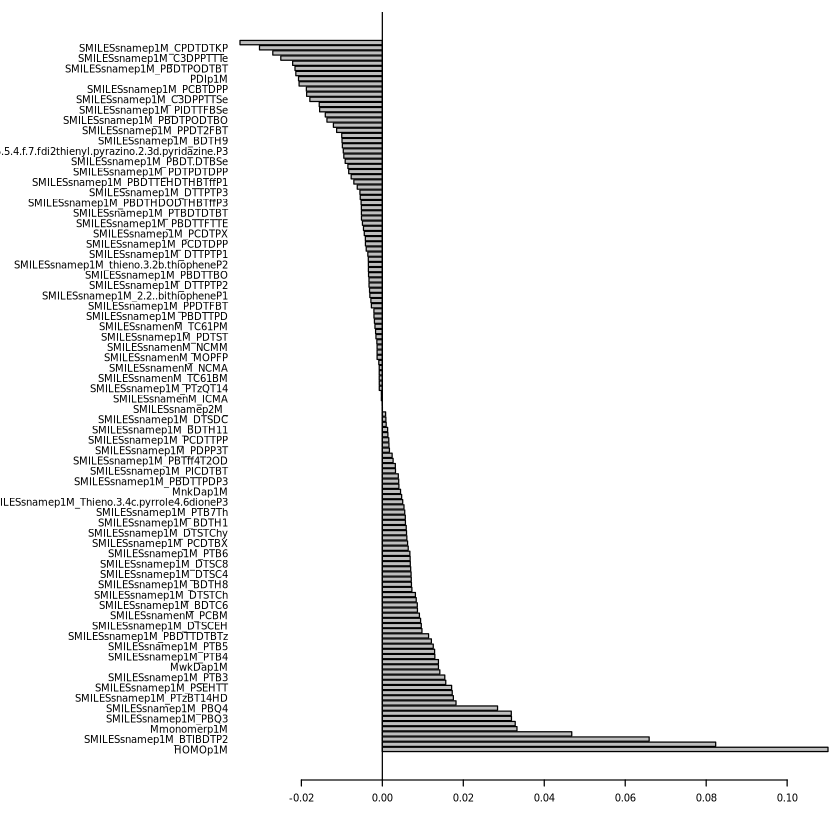

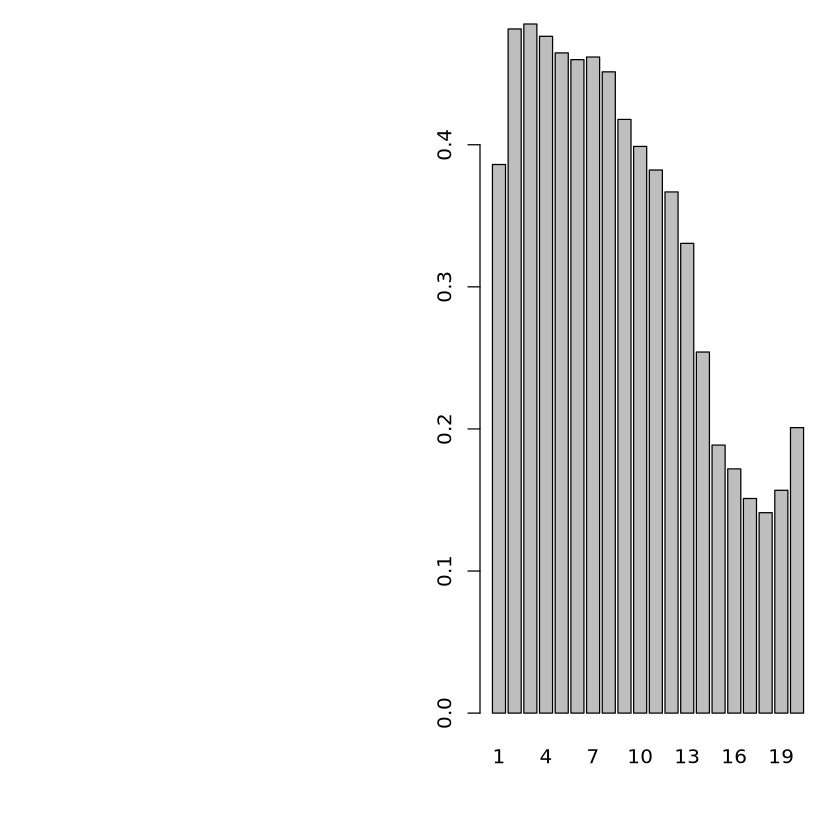

R2      = 0.7693 
corALL  = 0.8771 
RMSE    = 0.0535 


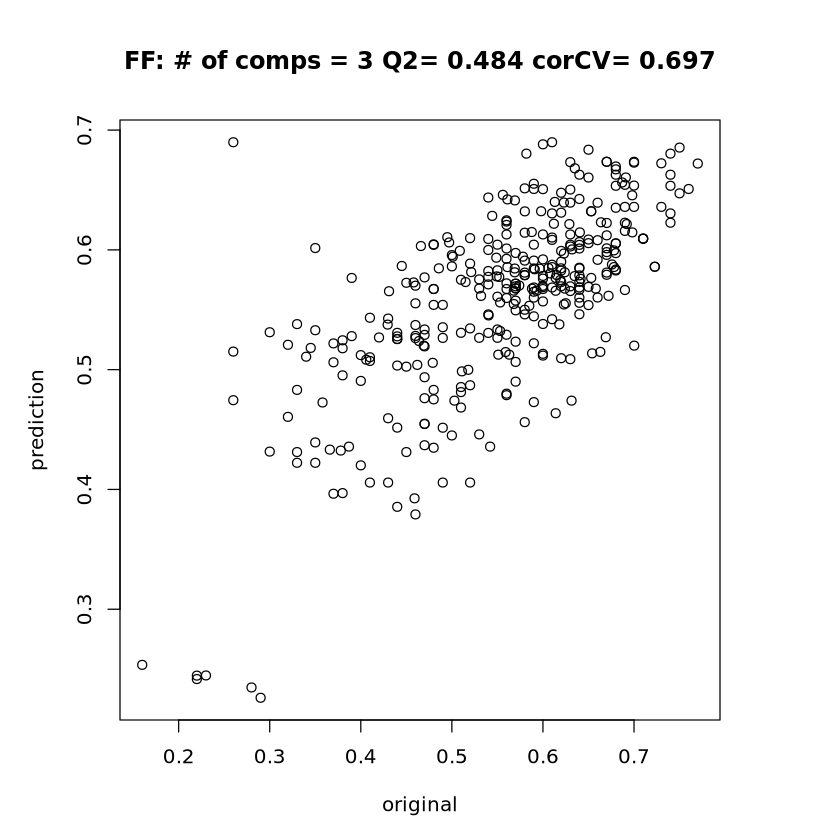


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                     SMILESsnamep1M_PffBT4T2OD 
                                                                                                       0.02559 
                                                                                                      MnkDap1M 
                                                                                                       0.01424 
                                                                                        SMILESsnamep1M_PBDTBDD 
                                                                                                       0.01424 
                                                                                     SMILESsnamep1M_PBTff4T2OD 
                                                                                                       0.01336 
                            

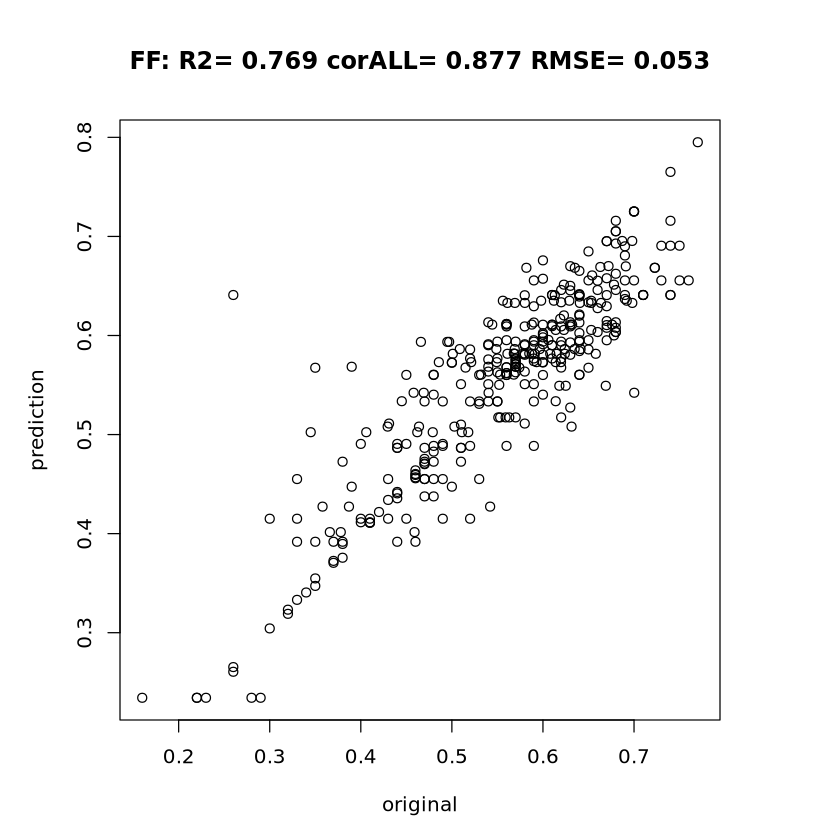


Target: PCEmax 


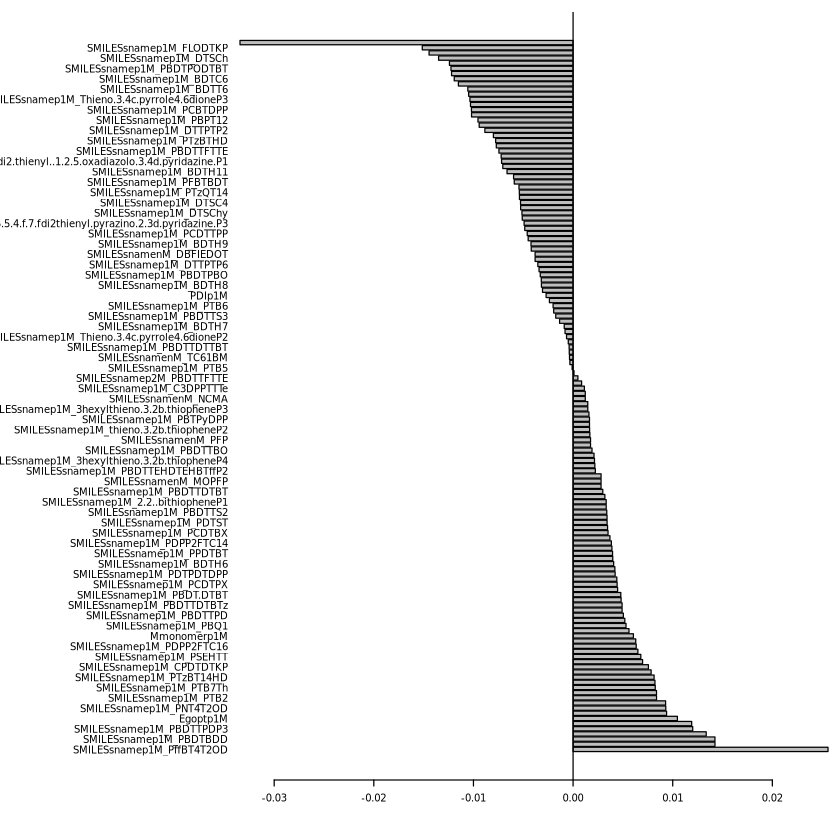

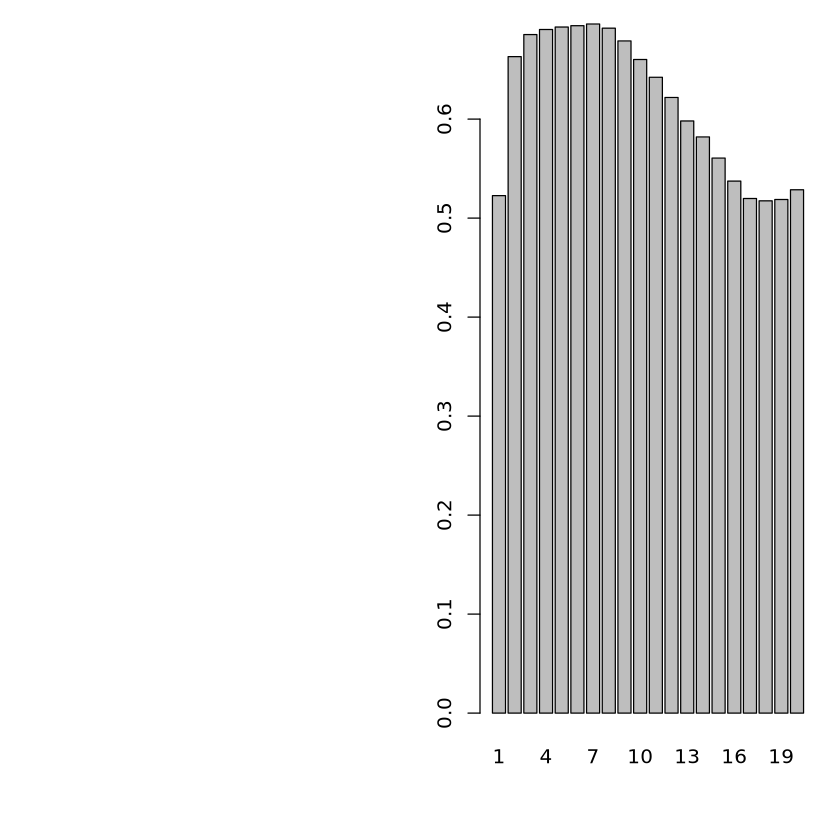

R2      = 0.8693 
corALL  = 0.9323 
RMSE    = 0.9546 


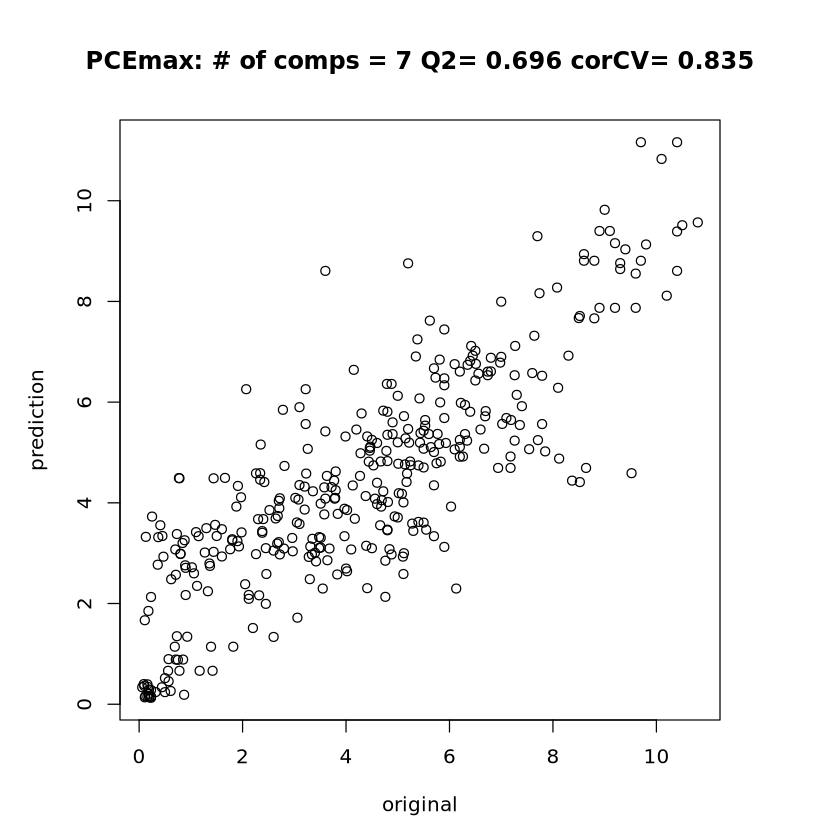


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                     SMILESsnamep1M_PffBT4T2OD 
                                                                                                       1.08014 
                                                                                     SMILESsnamep1M_PBTff4T2OD 
                                                                                                       0.50302 
                                                                                                      MnkDap1M 
                                                                                                       0.47489 
                                                                                       SMILESsnamep1M_PNT4T2OD 
                                                                                                       0.41253 
                            

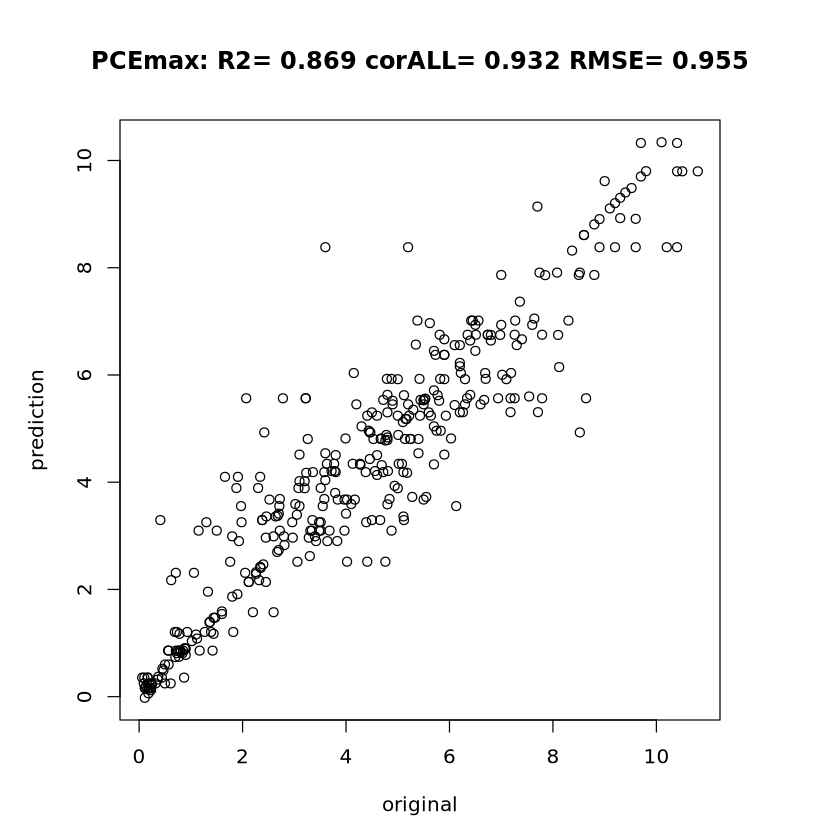

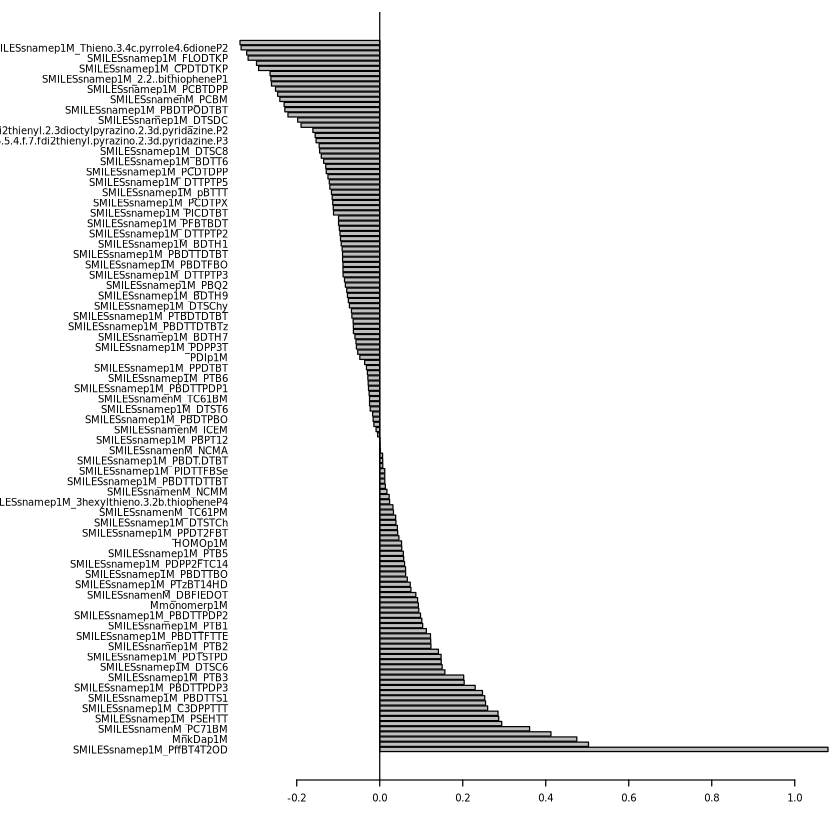

In [5]:
# --- ライブラリ読み込み ---
library(pls)
library(plsVarSel)
library(Metrics)

# --- データ読み込み・前処理 ---
ifname <- "20211223base_oh.csv"
readData <- read.delim(ifname, header=TRUE, sep=",", row.names=1, as.is=TRUE)
readData2 <- readData[, !sapply(readData, is.character)]

# --- 計算対象の目的変数 ---
target_y_list <- c("Jsc", "Voc", "FF", "PCEmax")

# --- 除外する列名 ---
rmlist <- c("Jsc", "Voc", "FF", "PCEmax", "PCEcal", "PCEdiff", "PCEave")

# --- 各目的変数について処理 ---
for (yname in target_y_list) {
  cat("\n=============================\n")
  cat("Target:", yname, "\n")
  cat("=============================\n")

  Y <- readData2[, yname]
  Xnames <- setdiff(colnames(readData2), rmlist)
  X <- readData2[, Xnames]
  
  # 欠損のある列を除去
  Nadata <- is.na(X)
  NNa <- colSums(Nadata)
  XX <- X[, NNa == 0]

  # 欠損行除去
  dMerge <- data.frame(Y, XX)
  Nadata <- na.omit(dMerge)

  # 標準偏差チェックとスケーリング
  sdcheck <- apply(Nadata, 2, sd)
  TF <- sdcheck != 0
  ssd <- scale(Nadata[, TF])
  ssd[, 1] <- Nadata[, 1]  # Yは非スケーリングで戻す
  YXdata <- data.frame(ssd)

  # --- PLS モデル構築 ---
  set.seed(123)
  result1.pls <- plsr(Y ~ ., data=YXdata, scale=FALSE, validation="CV", segments=10)
  plspress <- result1.pls$validation$PRESS
  ncomponent <- which.min(plspress)
  Ypred1 <- result1.pls$validation$pred[,,ncomponent]

  # --- Q2 の計算と表示 ---
  tss <- sum((YXdata[,1] - mean(YXdata[,1]))^2)
  Q2 <- 1 - plspress / tss
  mc <- which.max(Q2)
  corCV <- cor(YXdata[,1], Ypred1)

  par(cex=1.0)
  barplot(Q2[1:20], names.arg=1:20)
  titleR <- paste0(yname, ": # of comps = ", mc,
                   " Q2= ", substring(max(Q2),1,5),
                   " corCV= ", substring(corCV,1,5))
  par(mar=c(5,5,5,5))
  plot(YXdata[,1], Ypred1, xlab="original", ylab="prediction", main=titleR)

  # --- モデルからの予測値と R2・RMSE の表示 ---
  Ypred2 <- predict(result1.pls, newdata=YXdata, ncomp=ncomponent)
  rss <- sum((YXdata[,1] - Ypred2)^2)
  R2 <- 1 - rss / tss
  CR <- cor(YXdata[,1], Ypred2)
  RMSEval <- rmse(YXdata[,1], Ypred2)

  cat("R2      =", round(R2, 4), "\n")
  cat("corALL  =", round(CR, 4), "\n")
  cat("RMSE    =", round(RMSEval, 4), "\n")

  titleR2 <- paste0(yname, ": R2= ", substring(R2,1,5),
                    " corALL= ", substring(CR,1,5),
                    " RMSE= ", round(RMSEval, 3))
  plot(YXdata[,1], Ypred2, xlab="original", ylab="prediction", main=titleR2)

  # --- 回帰係数の表示（数値） ---
  coefs <- coefficients(result1.pls, ncomp=ncomponent)[,1,1]
  sorted_coefs <- sort(coefs, decreasing=TRUE)
  cat("\n[回帰係数ランキング]\n")
  print(round(sorted_coefs, 5))

  # --- 回帰係数の棒グラフ ---
  par(cex=0.5)
  par(mar=c(5,20,1,1))
  barplot(sorted_coefs, horiz=TRUE, las=1)
  abline(v=0, lty=1)
}


In [3]:
getwd()


[1] "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n-base-OH SMILES"


Target: Jsc 
R2      = 0.8968 
corALL  = 0.947 
RMSE    = 1.6229 
MAE     = 1.0783 
RPD     = 3.118 


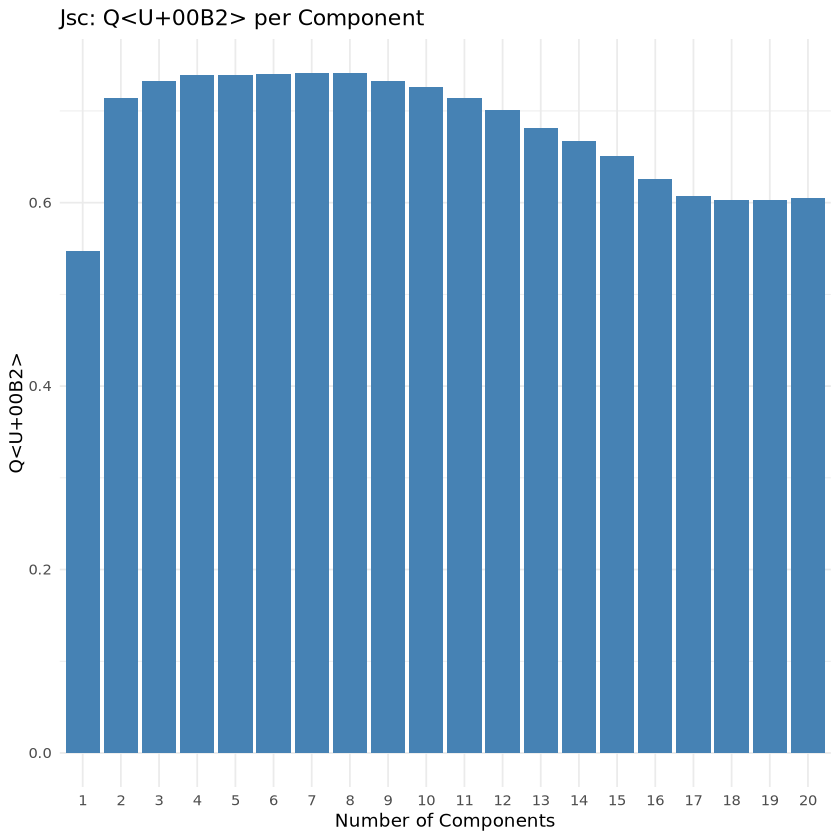


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                     SMILESsnamep1M_PffBT4T2OD 
                                                                                                       1.62329 
                                                                                                      MnkDap1M 
                                                                                                       1.01119 
                                                                                       SMILESsnamep1M_C3DPPTTT 
                                                                                                       0.92532 
                                                                                     SMILESsnamep1M_PBTff4T2OD 
                                                                                                       0.79806 
                            

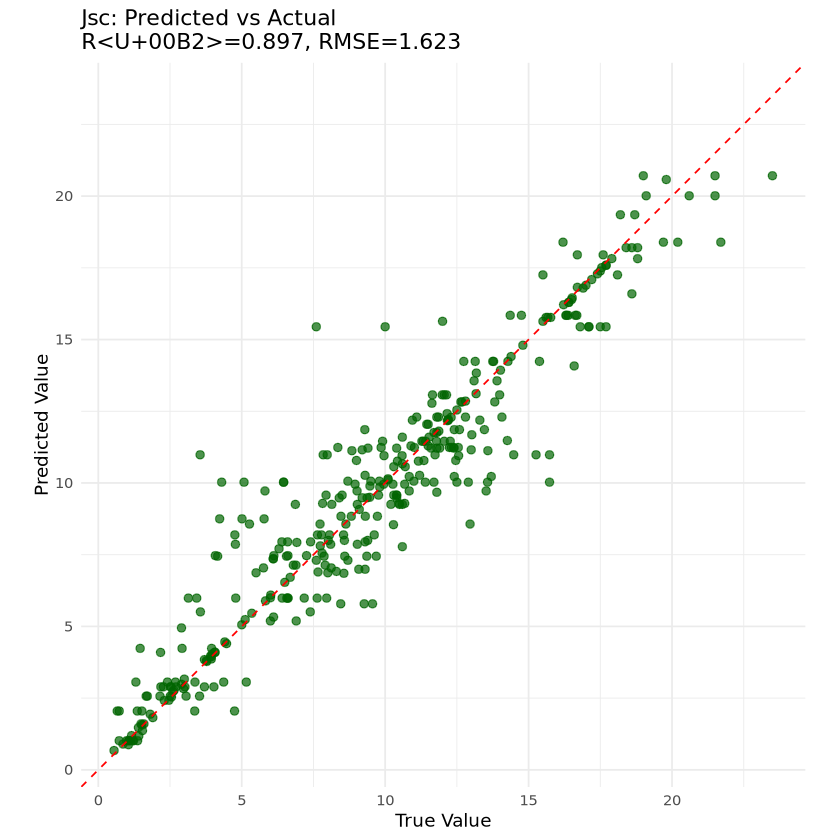

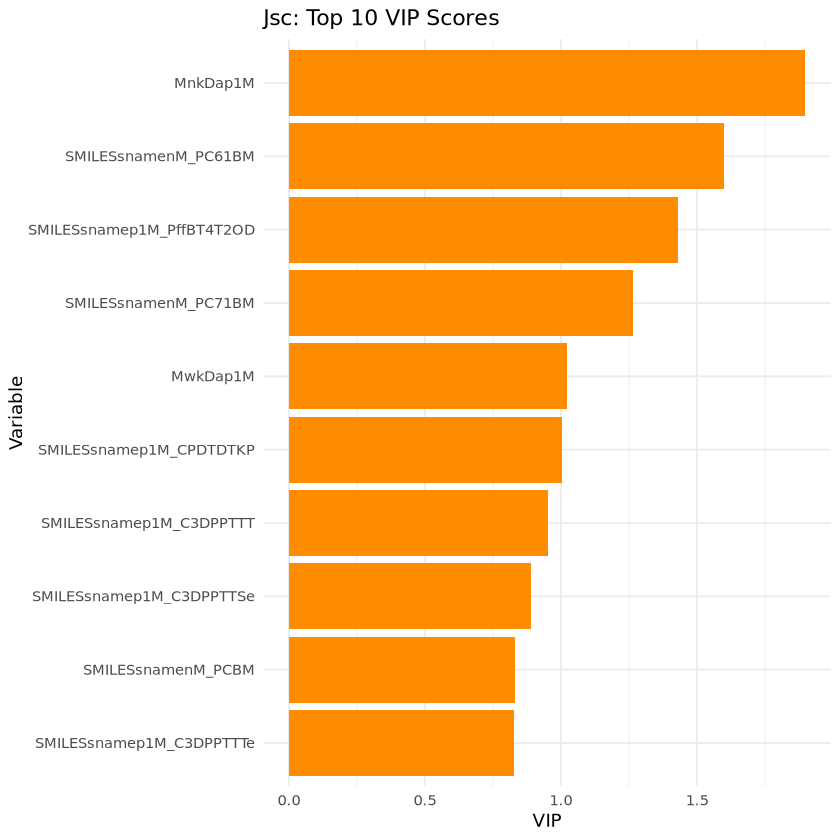


Target: Voc 
R2      = 0.9511 
corALL  = 0.9753 
RMSE    = 0.0335 
MAE     = 0.0187 
RPD     = 4.53 


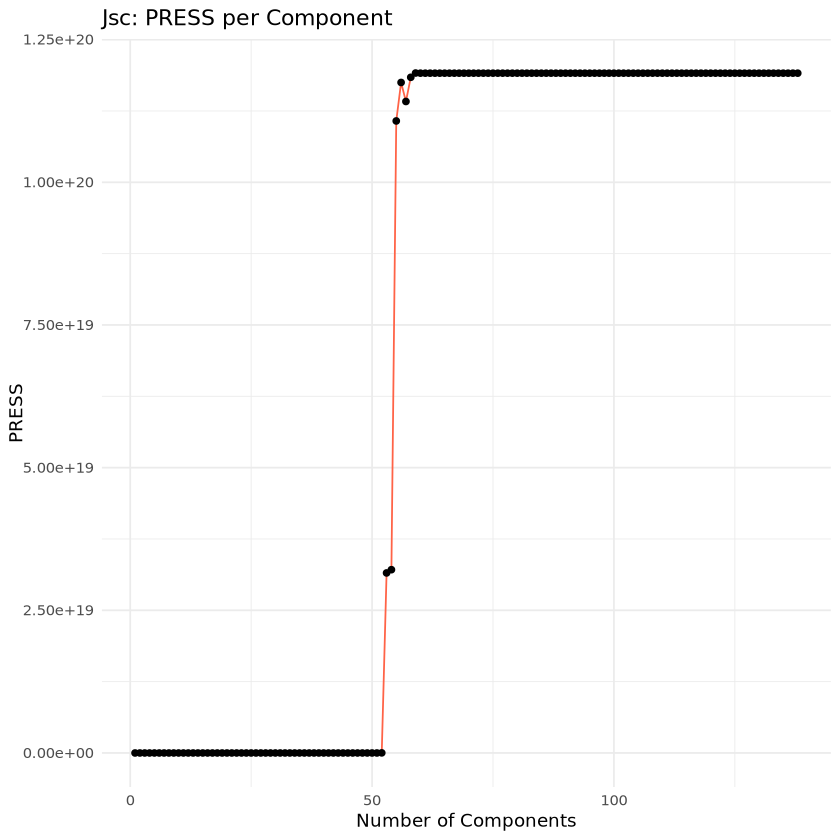

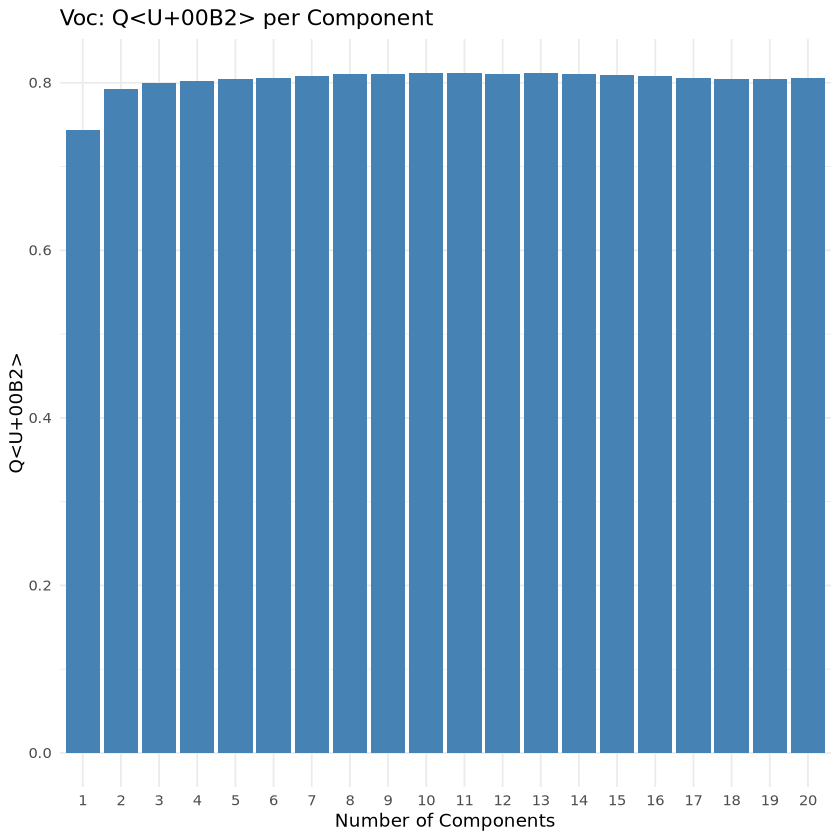


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                                       HOMOp1M 
                                                                                                       0.11009 
                                                                                                       LUMOp1M 
                                                                                                       0.08235 
                                                                                       SMILESsnamep1M_BTIBDTP2 
                                                                                                       0.06591 
                                                                                           SMILESsnamep1M_PBQ1 
                                                                                                       0.04679 
                            

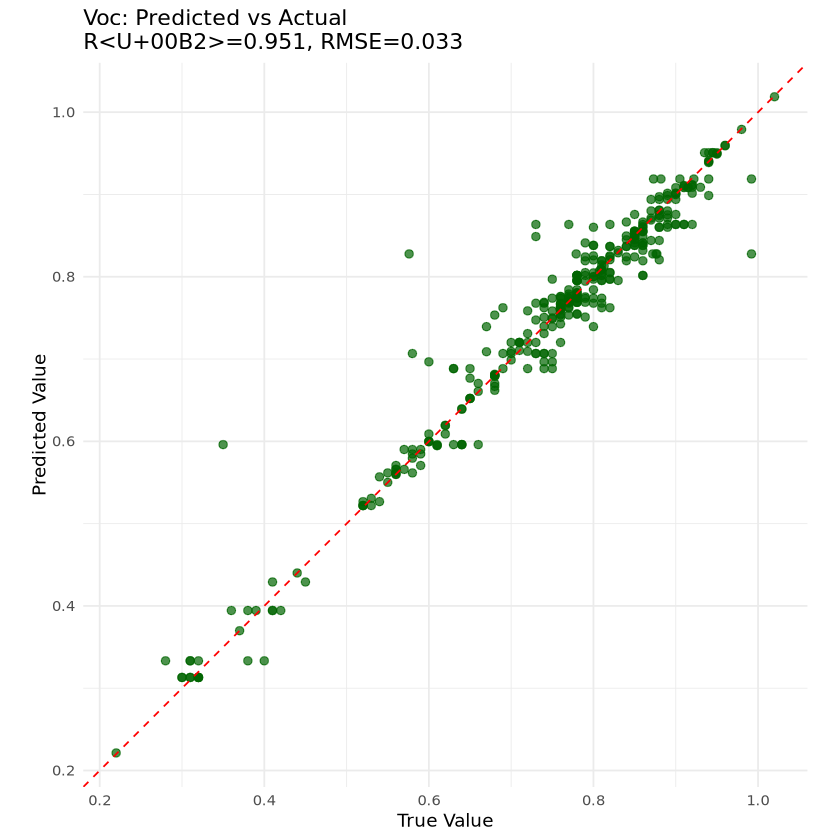

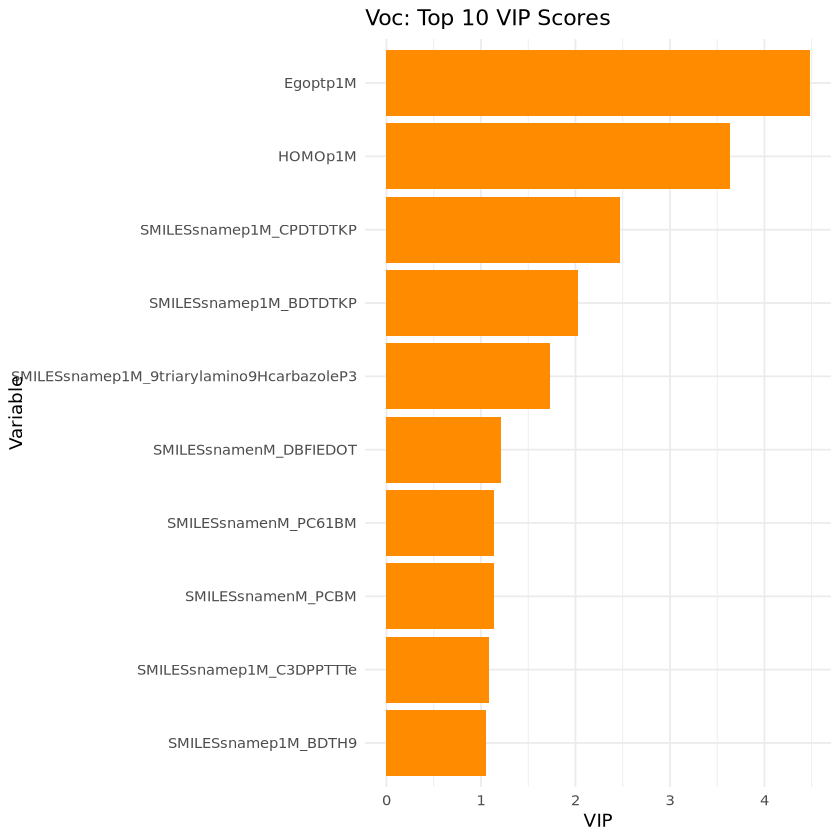


Target: FF 
R2      = 0.7693 
corALL  = 0.8771 
RMSE    = 0.0535 
MAE     = 0.0374 
RPD     = 2.085 


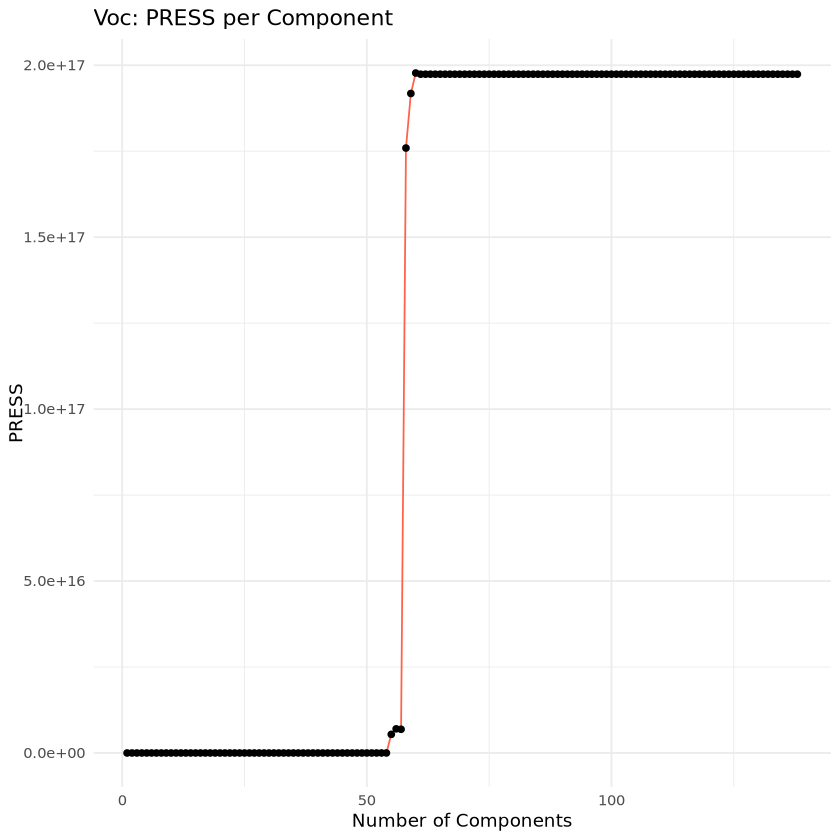

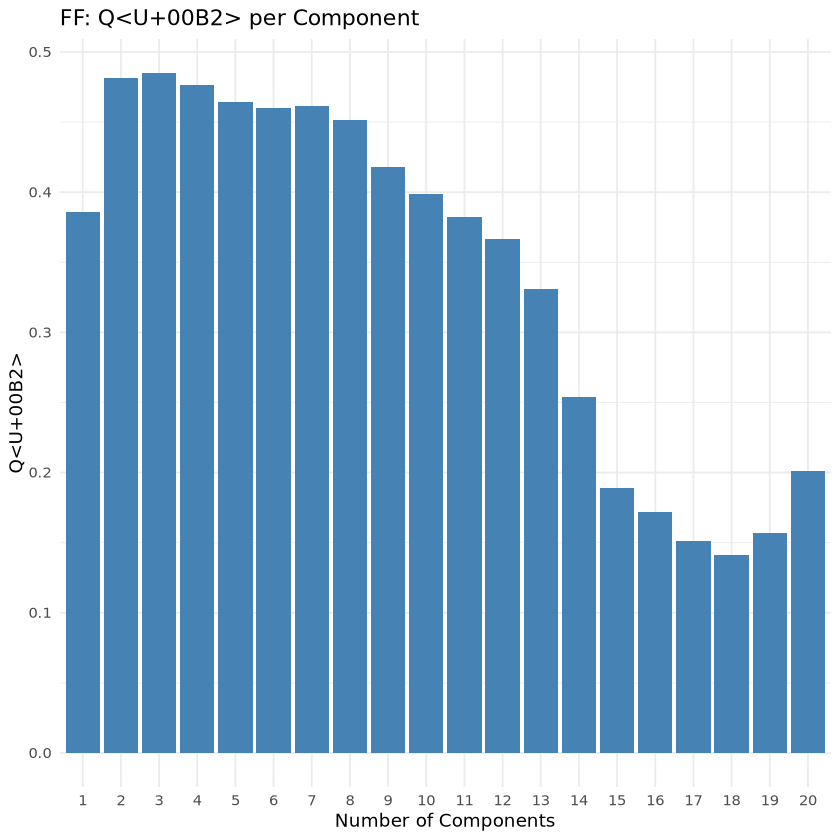


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                     SMILESsnamep1M_PffBT4T2OD 
                                                                                                       0.02559 
                                                                                                      MnkDap1M 
                                                                                                       0.01424 
                                                                                        SMILESsnamep1M_PBDTBDD 
                                                                                                       0.01424 
                                                                                     SMILESsnamep1M_PBTff4T2OD 
                                                                                                       0.01336 
                            

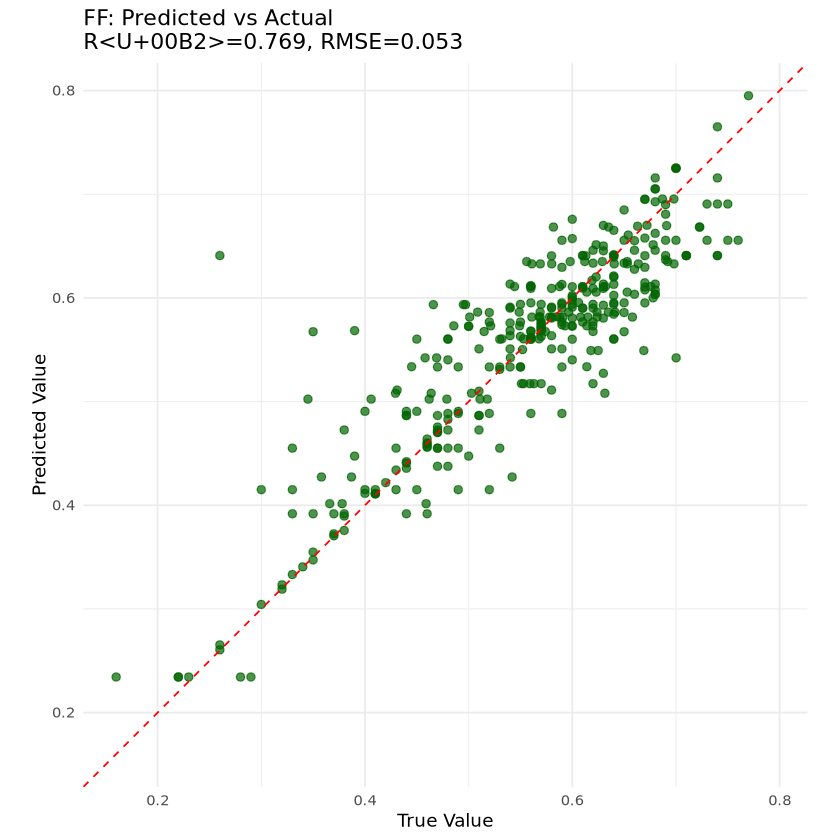

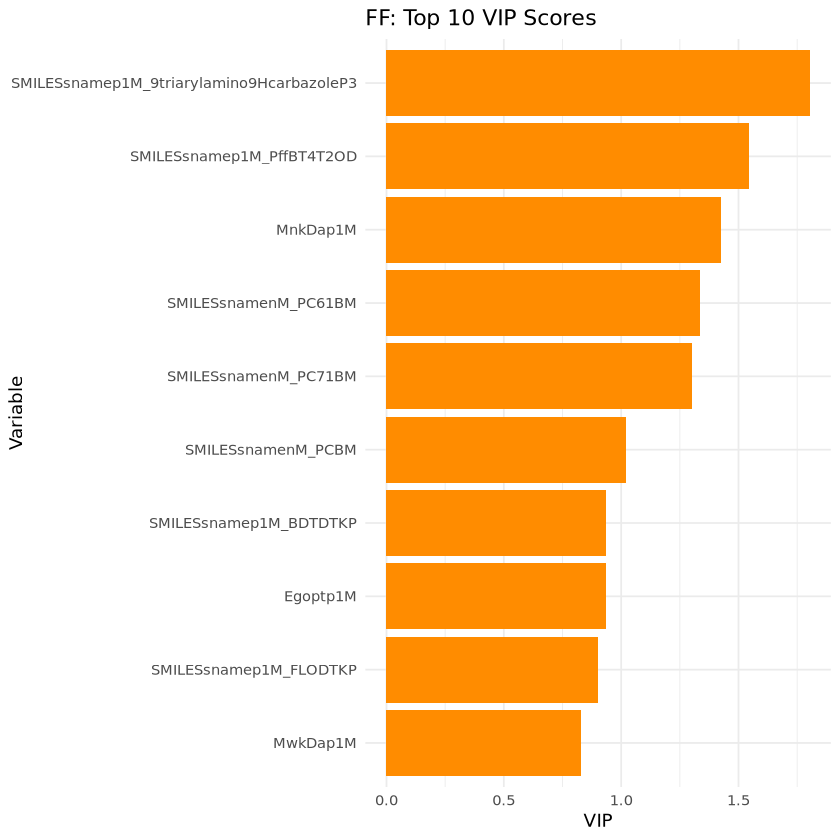


Target: PCEmax 
R2      = 0.8693 
corALL  = 0.9323 
RMSE    = 0.9546 
MAE     = 0.6399 
RPD     = 2.769 


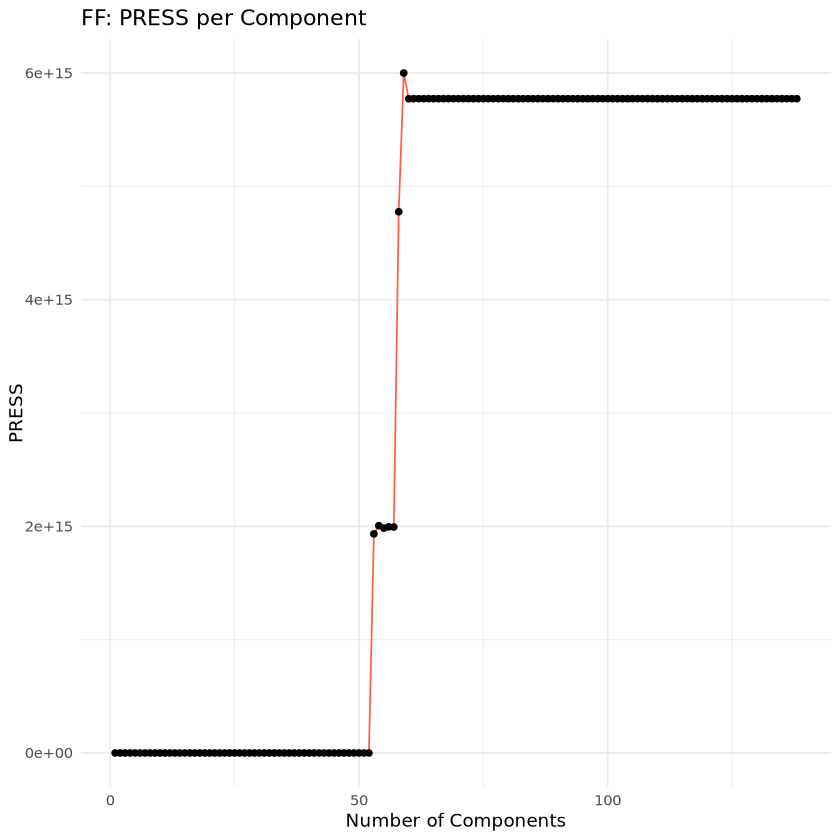

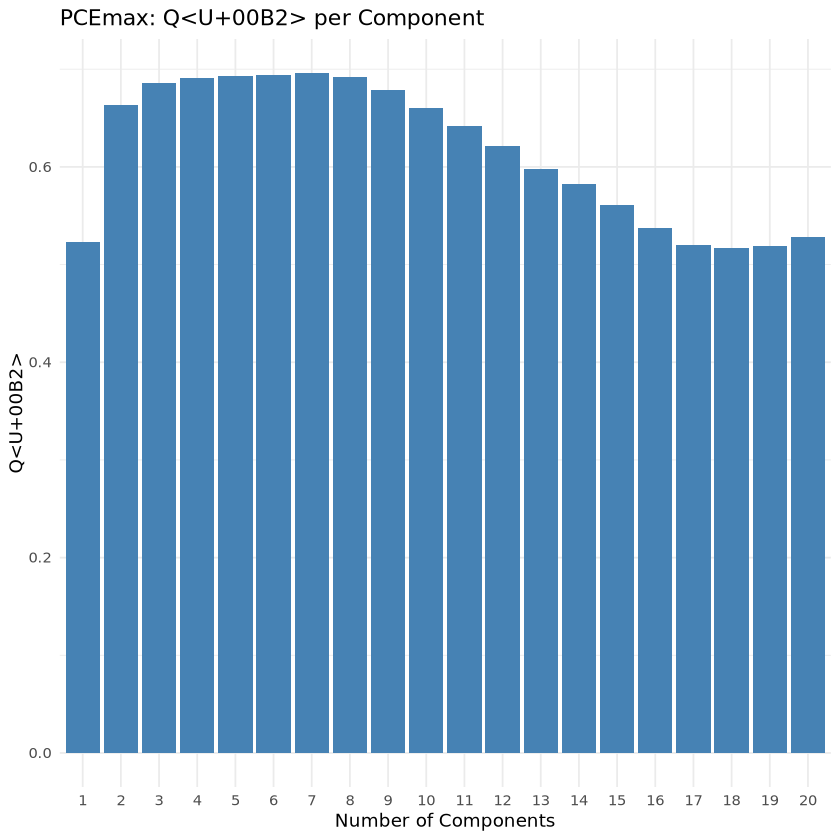


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
                                                                                     SMILESsnamep1M_PffBT4T2OD 
                                                                                                       1.08014 
                                                                                     SMILESsnamep1M_PBTff4T2OD 
                                                                                                       0.50302 
                                                                                                      MnkDap1M 
                                                                                                       0.47489 
                                                                                       SMILESsnamep1M_PNT4T2OD 
                                                                                                       0.41253 
                            

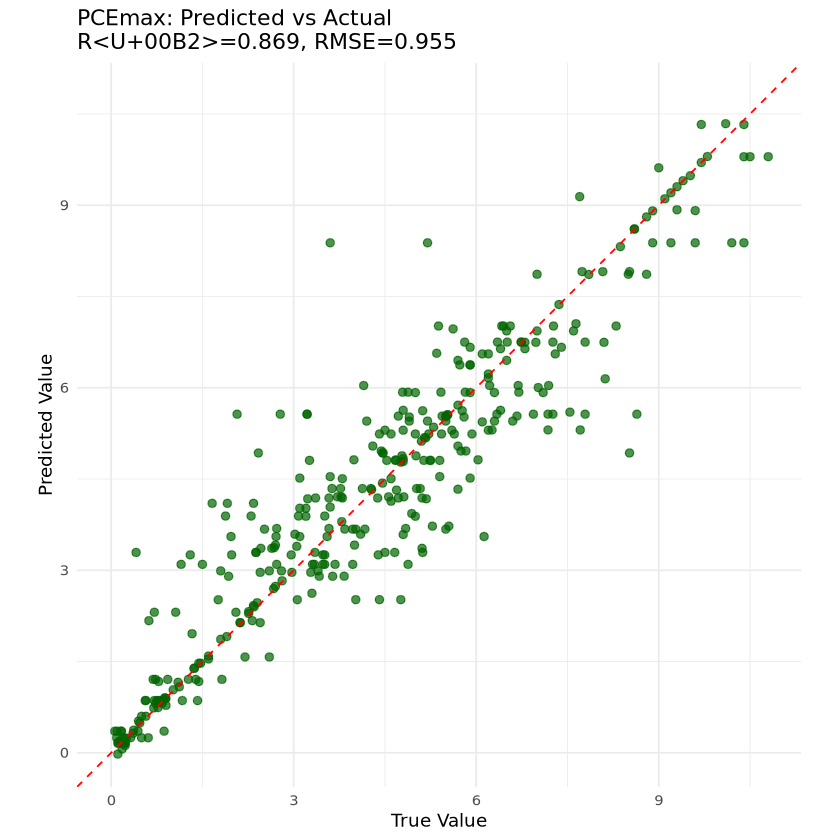

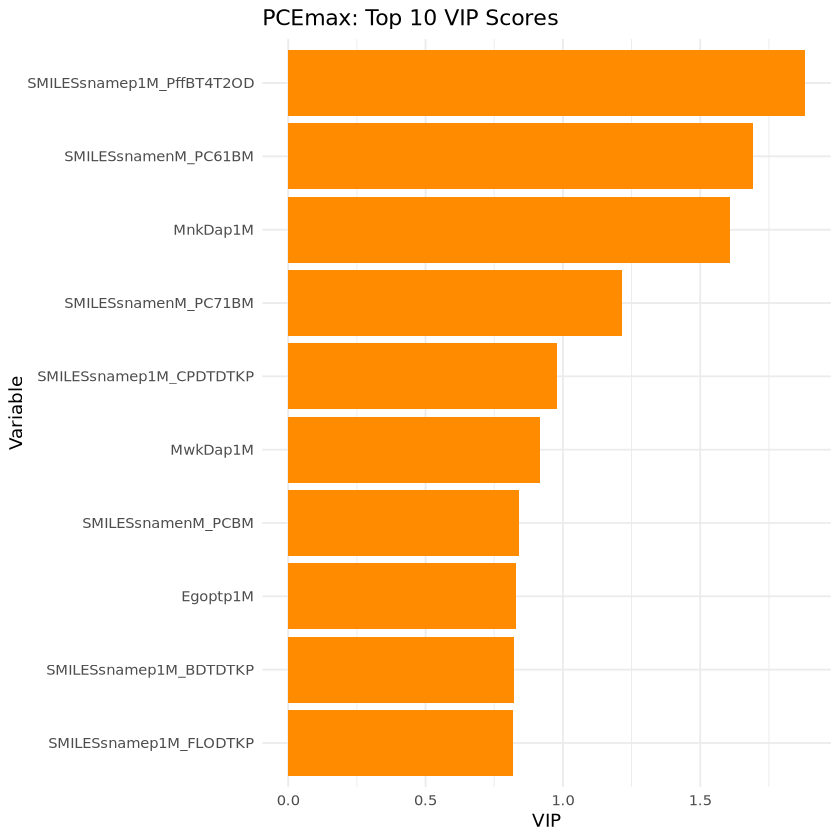

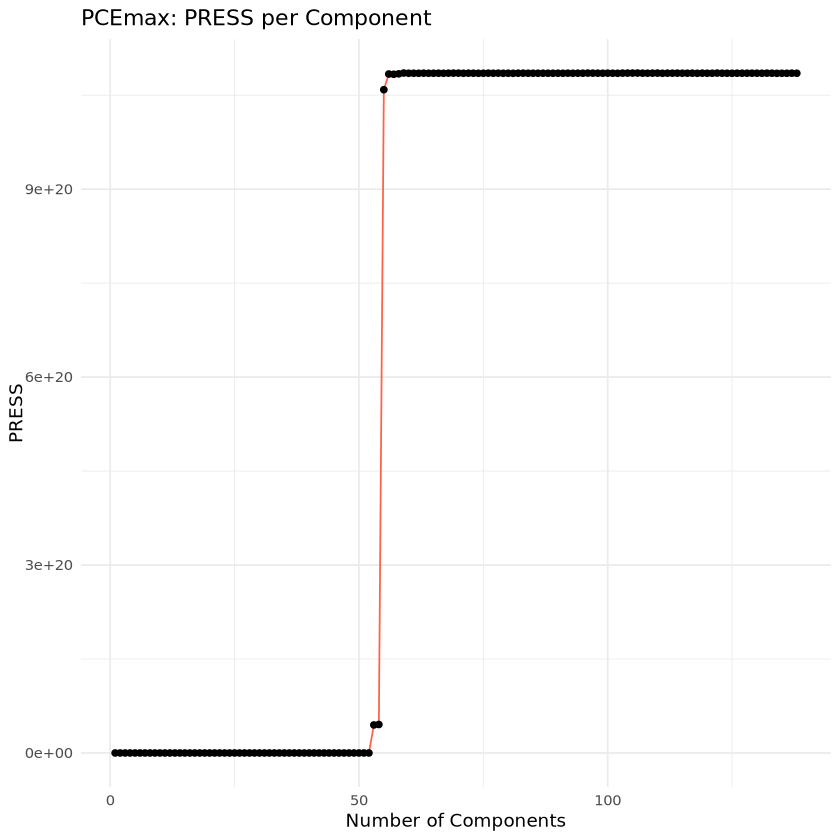

In [6]:
# 必要なパッケージ読み込み
library(pls)
library(plsVarSel)
library(Metrics)
library(ggplot2)

# --- VIPスコアの計算関数（安全版） ---
calc_vip <- function(pls_model, ncomp) {
  max_comp <- min(ncomp, nrow(pls_model$Yloadings))  # 安全性確保
  SS <- pls_model$Yloadings[1:max_comp, , drop = FALSE]^2
  W <- pls_model$loading.weights[, 1:max_comp, drop = FALSE]
  p <- nrow(W)
  Wnorm2 <- colSums(W^2)
  SSY <- sum(SS)

  vip_scores <- numeric(p)
  for (j in 1:p) {
    weight <- 0
    for (a in 1:max_comp) {
      if (Wnorm2[a] == 0) next  # ゼロ除算防止
      weight <- weight + SS[a] * (W[j, a]^2 / Wnorm2[a])
    }
    vip_scores[j] <- sqrt(p * weight / SSY)
  }
  names(vip_scores) <- rownames(W)
  return(vip_scores)
}

# --- データ読み込み ---
ifname <- "20211223base_oh.csv"
readData <- read.delim(ifname, header=TRUE, sep=",", row.names=1, as.is=TRUE)
readData2 <- readData[, !sapply(readData, is.character)]

target_y_list <- c("Jsc", "Voc", "FF", "PCEmax")
rmlist <- c("Jsc", "Voc", "FF", "PCEmax", "PCEcal", "PCEdiff", "PCEave")

for (yname in target_y_list) {
  cat("\n=============================\n")
  cat("Target:", yname, "\n")
  cat("=============================\n")

  Y <- readData2[, yname]
  Xnames <- setdiff(colnames(readData2), rmlist)
  X <- readData2[, Xnames]

  Nadata <- is.na(X)
  NNa <- colSums(Nadata)
  XX <- X[, NNa == 0]

  dMerge <- data.frame(Y, XX)
  Nadata <- na.omit(dMerge)
  sdcheck <- apply(Nadata, 2, sd)
  TF <- sdcheck != 0
  ssd <- scale(Nadata[, TF])
  ssd[, 1] <- Nadata[, 1]
  YXdata <- data.frame(ssd)

  set.seed(123)
  result1.pls <- plsr(Y ~ ., data=YXdata, scale=FALSE, validation="CV", segments=10)
  plspress <- result1.pls$validation$PRESS
  ncomponent <- which.min(plspress)

  Ypred1 <- result1.pls$validation$pred[,,ncomponent]
  tss <- sum((YXdata[,1] - mean(YXdata[,1]))^2)
  Q2 <- 1 - plspress / tss
  corCV <- cor(YXdata[,1], Ypred1)

  Ypred2 <- predict(result1.pls, newdata=YXdata, ncomp=ncomponent)
  rss <- sum((YXdata[,1] - Ypred2)^2)
  R2 <- 1 - rss / tss
  CR <- cor(YXdata[,1], Ypred2)
  RMSEval <- rmse(YXdata[,1], Ypred2)
  MAEval <- mae(YXdata[,1], Ypred2)
  sd_Y <- sd(YXdata[,1])
  RPDval <- sd_Y / RMSEval

  cat("R2      =", round(R2, 4), "\n")
  cat("corALL  =", round(CR, 4), "\n")
  cat("RMSE    =", round(RMSEval, 4), "\n")
  cat("MAE     =", round(MAEval, 4), "\n")
  cat("RPD     =", round(RPDval, 3), "\n")

  # Q2バーグラフ
  df_q2 <- na.omit(data.frame(Component = seq_along(Q2), Q2 = as.numeric(Q2)))
  print(
    ggplot(df_q2[1:20, ], aes(x = factor(Component), y = Q2)) +
      geom_bar(stat = "identity", fill = "steelblue") +
      labs(title = paste0(yname, ": Q² per Component"),
           x = "Number of Components", y = "Q²") +
      theme_minimal()
  )

  # 予測 vs 実測プロット
  df_pred <- data.frame(True = YXdata[,1], Predicted = as.vector(Ypred2))
  lims <- range(c(df_pred$True, df_pred$Predicted), na.rm = TRUE)
  print(
    ggplot(df_pred, aes(x = True, y = Predicted)) +
      geom_point(color = "darkgreen", alpha = 0.7, size = 2) +
      geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
      labs(title = paste0(yname, ": Predicted vs Actual\nR²=", round(R2, 3), ", RMSE=", round(RMSEval, 3)),
           x = "True Value", y = "Predicted Value") +
      coord_fixed(ratio = 1, xlim = lims, ylim = lims) +
      theme_minimal()
  )

  # 回帰係数
  coefs <- coefficients(result1.pls, ncomp=ncomponent)[,1,1]
  sorted_coefs <- sort(coefs, decreasing=TRUE)
  cat("\n[回帰係数ランキング]\n")
  print(round(sorted_coefs, 5))

  # VIPスコア
  vip_scores <- calc_vip(result1.pls, ncomponent)
  vip_sorted <- sort(vip_scores, decreasing = TRUE)
  cat("\n[VIPスコア上位変数]\n")
  print(round(vip_sorted[1:10], 3))

  df_vip <- data.frame(Variable = names(vip_sorted[1:10]), VIP = vip_sorted[1:10])
  df_vip$Variable <- factor(df_vip$Variable, levels = rev(df_vip$Variable))
  print(
    ggplot(df_vip, aes(x = Variable, y = VIP)) +
      geom_bar(stat = "identity", fill = "darkorange") +
      coord_flip() +
      labs(title = paste0(yname, ": Top 10 VIP Scores")) +
      theme_minimal()
  )

  # PRESSプロット
  press_df <- data.frame(Component = seq_along(plspress), PRESS = as.numeric(plspress))
  print(
    ggplot(press_df, aes(x = Component, y = PRESS)) +
      geom_line(color = "tomato") +
      geom_point() +
      theme_minimal() +
      labs(title = paste0(yname, ": PRESS per Component"),
           x = "Number of Components", y = "PRESS")
  )
} 
